In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import pandas as pd
import re

In [ ]:
songs = pd.read_csv("/content/drive/MyDrive/music_genre.csv")
spotify = pd.read_csv("/content/drive/MyDrive/dataset.csv")

print("Songs shape:", songs.shape)
print("Spotify shape:",   spotify.shape)

print("\nSongs columns:", songs.columns.tolist())
print("Spotify columns:",   spotify.columns.tolist())

Songs shape: (50005, 18)
Spotify shape: (114000, 21)

Songs columns: ['instance_id', 'artist_name', 'track_name', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'obtained_date', 'valence', 'music_genre']
Spotify columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [ ]:
songs.columns = songs.columns.str.strip().str.lower()
spotify.columns   = spotify.columns.str.strip().str.lower()

print("Songs columns:", songs.columns.tolist())
print("Spotify columns:",   spotify.columns.tolist())

Songs columns: ['instance_id', 'artist_name', 'track_name', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'obtained_date', 'valence', 'music_genre']
Spotify columns: ['unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [ ]:
# Cleaning data
import pandas as pd
import re

def clean_name(s):
    if pd.isna(s):
        return ""
    s = s.lower().strip()
    s = re.sub(r"\(.*?\)", "", s)
    s = re.sub(r"\[.*?\]", "", s)
    s = re.sub(r"[^a-z0-9 ]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# Clean track and artist name columns
songs["track_clean"]   = songs["track_name"].apply(clean_name)
spotify["track_clean"] = spotify["track_name"].apply(clean_name)
songs["artist_clean"]   = songs["artist_name"].str.lower().str.strip()
spotify["artist_clean"] = spotify["artists"].str.lower().str.strip()

# Drop bad rows
songs = songs.dropna(subset=["music_genre"])
songs = songs[songs["music_genre"].str.strip() != ""]
songs = songs[songs["music_genre"] != "Unknown"]
spotify = spotify.dropna(subset=["track_genre"])

# Deduplicate spotify (keep highest popularity per track+artist)
spotify = (
    spotify
    .sort_values("popularity", ascending=False)
    .drop_duplicates(subset=["track_clean", "artist_clean"])
    .reset_index(drop=True)
)

print("After cleaning:")
print(f"  songs:   {songs.shape}")
print(f"  spotify: {spotify.shape}")
print(f"\nSongs genre distribution:\n{songs['music_genre'].value_counts()}")

After cleaning:
  songs:   (50000, 20)
  spotify: (77999, 23)

Songs genre distribution:
music_genre
Electronic     5000
Anime          5000
Jazz           5000
Alternative    5000
Country        5000
Rap            5000
Blues          5000
Rock           5000
Classical      5000
Hip-Hop        5000
Name: count, dtype: int64


In [ ]:
# merging data

merged = songs.merge(
    spotify[["track_clean", "artist_clean", "track_id",
             "album_name", "explicit", "time_signature", "track_genre"]],
    on=["track_clean", "artist_clean"],
    how="left"
)

# Rename target variable
merged = merged.rename(columns={"music_genre": "genre"})

# Select final columns
audio_features = [
    "danceability", "energy", "valence", "acousticness",
    "tempo", "loudness", "speechiness", "instrumentalness",
    "liveness", "duration_ms", "key", "mode"
]

final_cols = ["artist_name", "track_name", "genre", "popularity"] + audio_features
merged = merged[final_cols].dropna(subset=audio_features)
merged.to_csv('dashboard_eda_data.csv', index=False)

print(f"Final dataset shape: {merged.shape}")
print(f"\nGenre distribution:\n{merged['genre'].value_counts()}")
print(f"\nMissing values:\n{merged.isnull().sum()}")

Final dataset shape: (50000, 16)

Genre distribution:
genre
Electronic     5000
Anime          5000
Jazz           5000
Alternative    5000
Country        5000
Rap            5000
Blues          5000
Rock           5000
Classical      5000
Hip-Hop        5000
Name: count, dtype: int64

Missing values:
artist_name         0
track_name          0
genre               0
popularity          0
danceability        0
energy              0
valence             0
acousticness        0
tempo               0
loudness            0
speechiness         0
instrumentalness    0
liveness            0
duration_ms         0
key                 0
mode                0
dtype: int64


/tmp/ipykernel_4931/165268188.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="viridis")


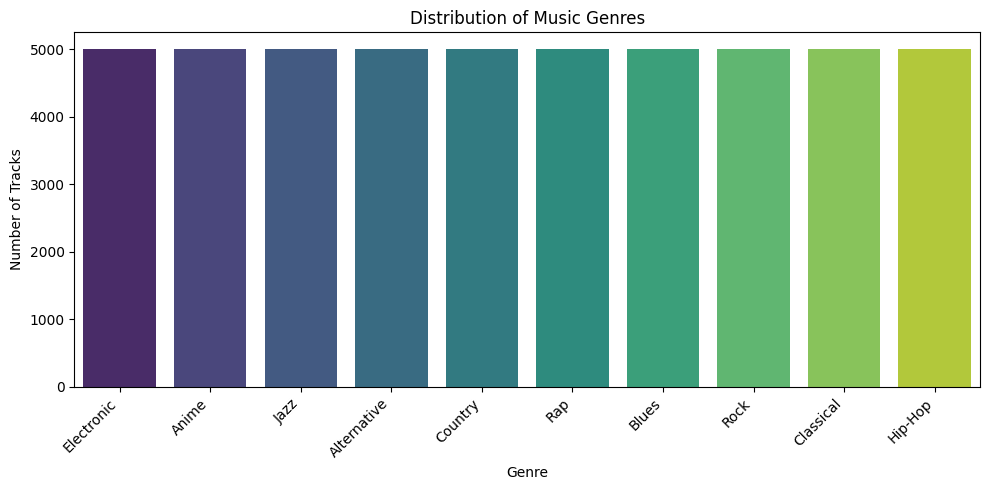

genre
Electronic     5000
Anime          5000
Jazz           5000
Alternative    5000
Country        5000
Rap            5000
Blues          5000
Rock           5000
Classical      5000
Hip-Hop        5000
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
genre_counts = merged["genre"].value_counts()
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="viridis")
plt.title("Distribution of Music Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(genre_counts)


## EDA 1: Genre Distribution

The dataset contains 10 genres with exactly 5,000 tracks each (50,000 total), making
the class distribution perfectly balanced. This means accuracy is a meaningful metric
and aggressive resampling like SMOTE is unnecessary. We will still pass
`class_weight='balanced'` into our classifiers as a precaution.

The 10 genres span a wide stylistic range, from Classical and Jazz to Electronic and
Hip-Hop. Some pairs (Classical vs. Electronic) should be easy to separate on audio
features alone, but others (Rap vs. Hip-Hop, Alternative vs. Rock) have a lot of overlapping characteristics (later confirmed by our model results
in Section 5.)

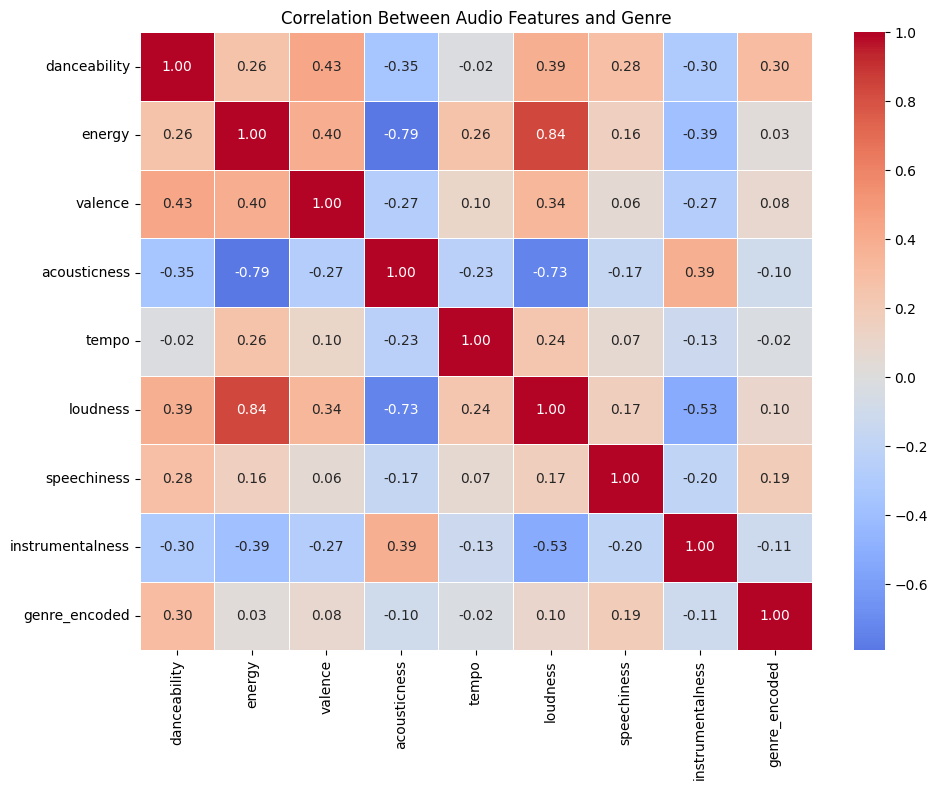

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd # Ensure pandas is imported

cols = ["danceability", "energy", "valence", "acousticness",
        "tempo", "loudness", "speechiness", "instrumentalness"]

# Convert columns to numeric, coercing errors to nan
# This handles non-numeric strings like '?' that dropna might miss
for col in cols:
    merged[col] = pd.to_numeric(merged[col], errors='coerce')

# Drop rows where any of the 'cols' values became nan after coercion
merged_cleaned = merged.dropna(subset=cols).copy()

# Add genre as numeric for correlation
temp = merged_cleaned[cols].copy()
temp["genre_encoded"] = LabelEncoder().fit_transform(merged_cleaned["genre"])

plt.figure(figsize=(10, 8))
sns.heatmap(temp.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5)
plt.title("Correlation Between Audio Features and Genre")
plt.tight_layout()
plt.show()

## EDA 2: Feature Correlation Heatmap

Energy and loudness are strongly positively correlated, suggesting they
carry redundant information so we may consider dropping one during feature
selection. Acousticness is strongly negatively correlated with energy,
which aligns with domain knowledge (acoustic songs tend to be quieter
and less produced). Genre shows moderate correlation with several features,
confirming that audio attributes are meaningful predictors.

/tmp/ipykernel_4931/1652530389.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_4931/1652530389.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_4931/1652530389.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_4931/1652530389.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_4931/1652530389.py:11: FutureWarn

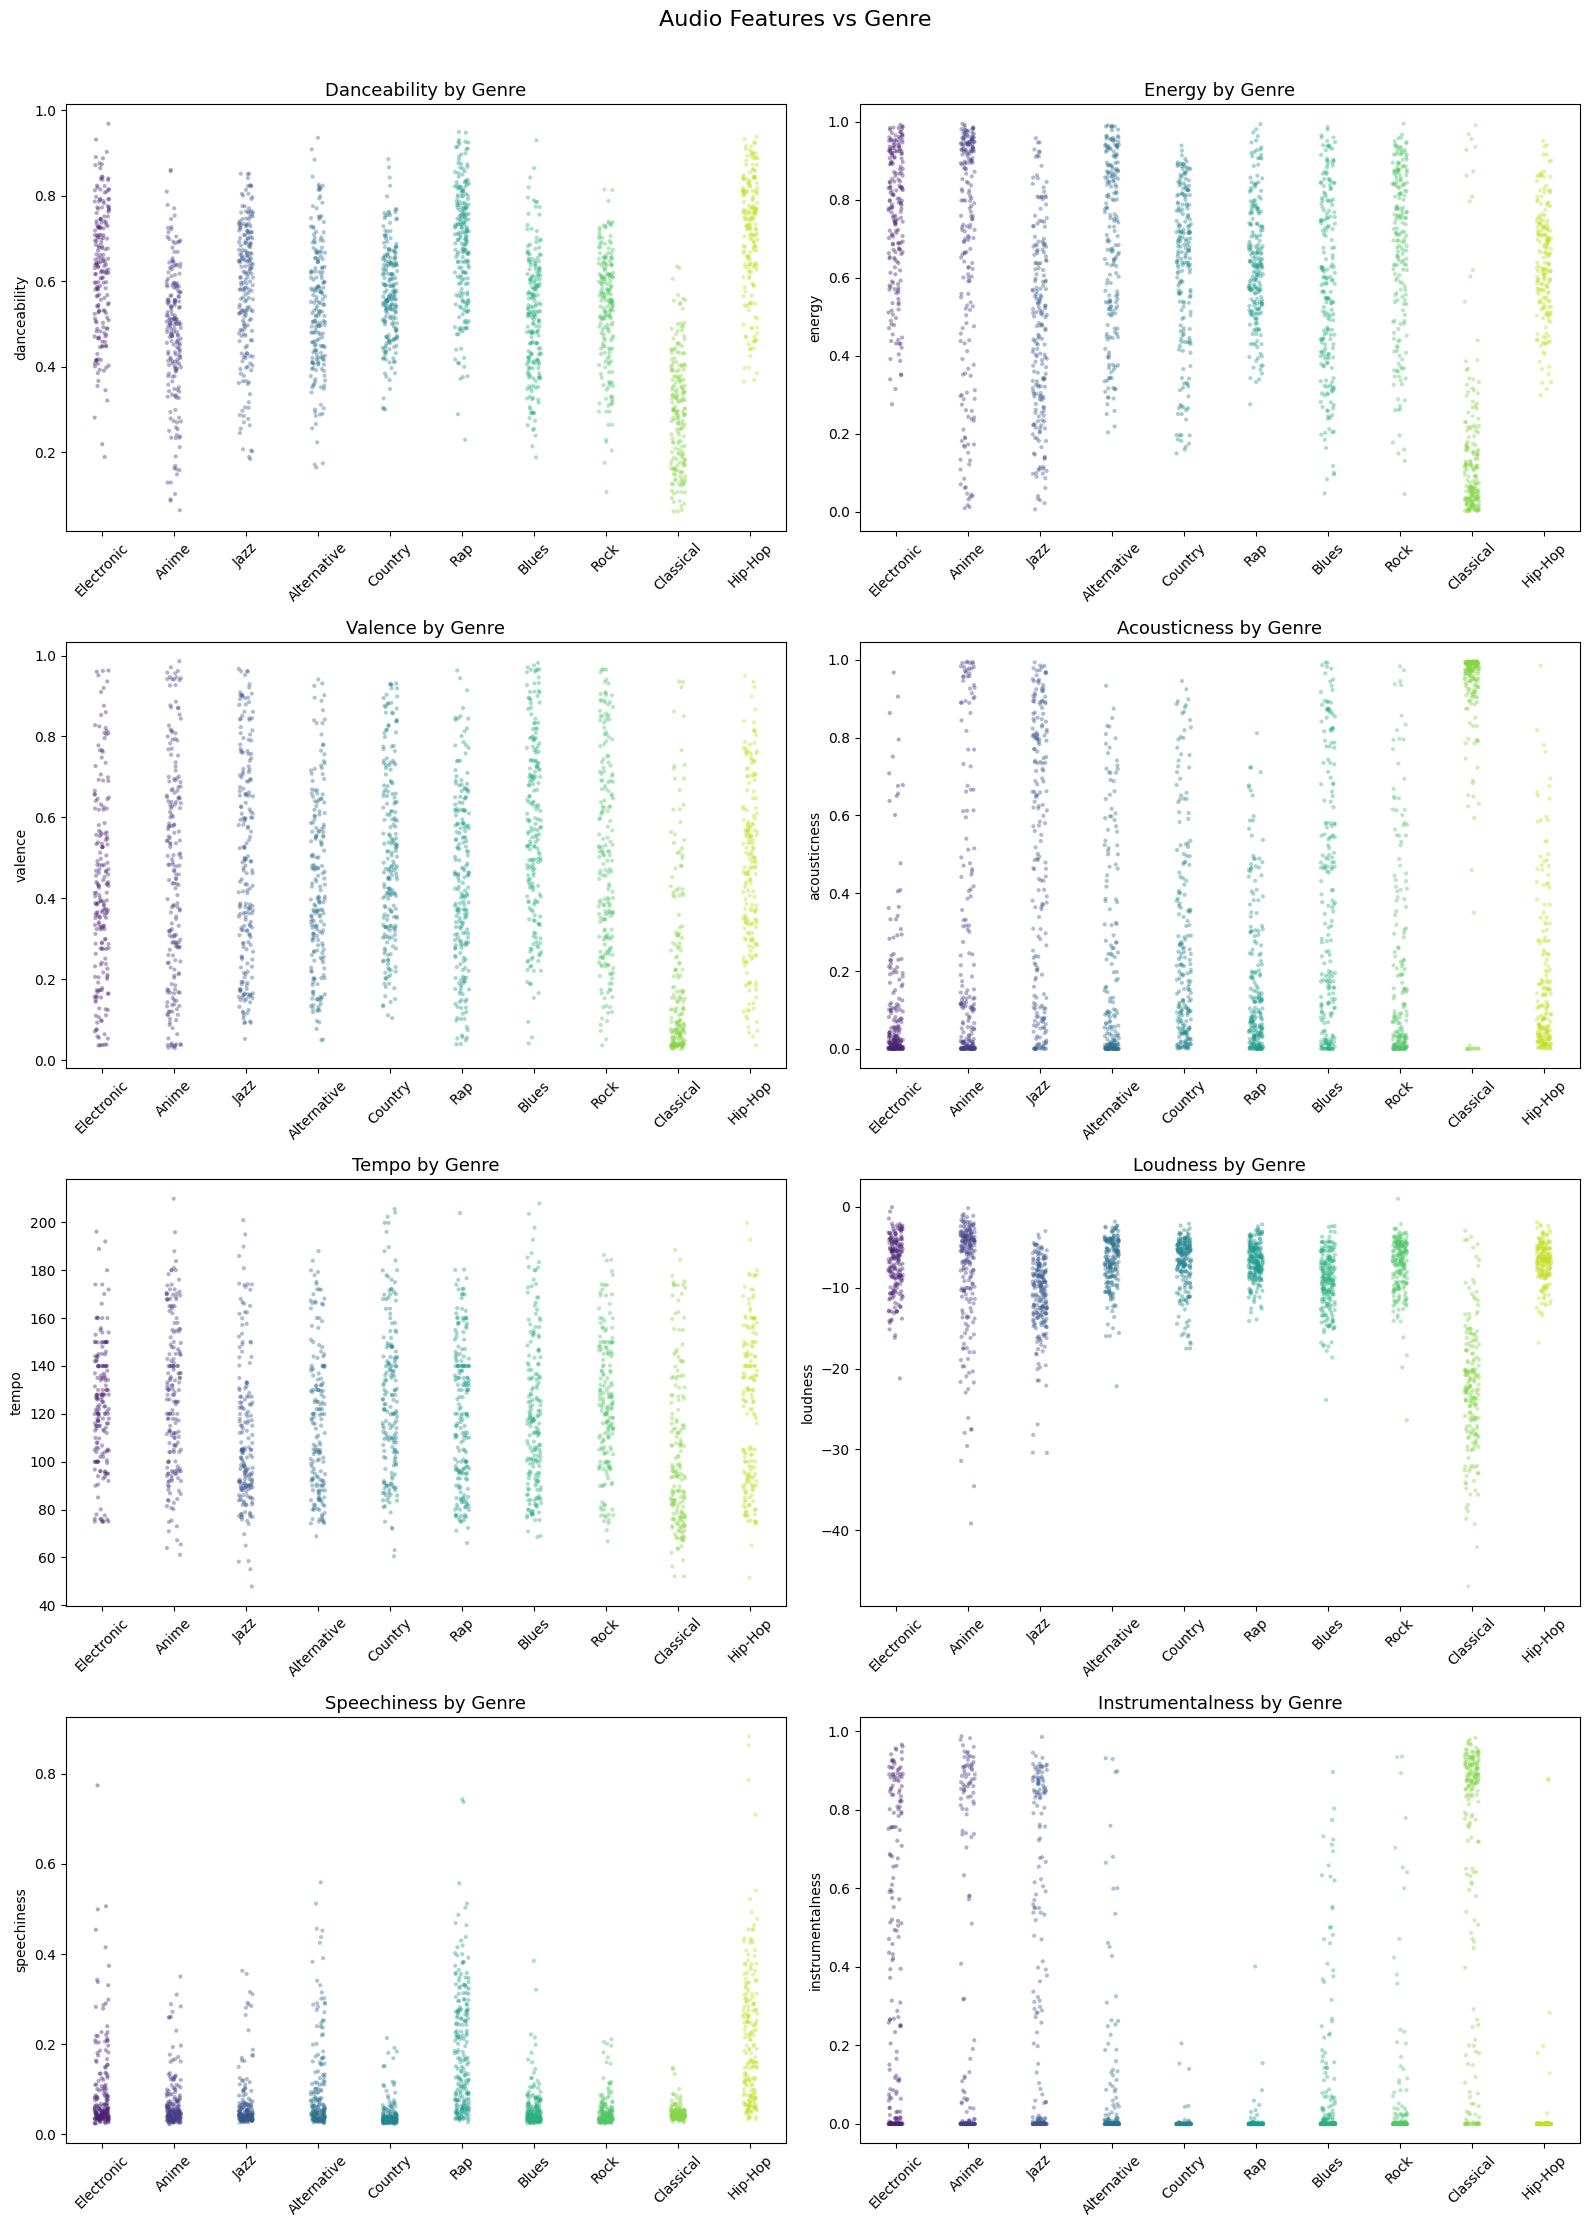

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ["danceability", "energy", "valence", "acousticness",
            "tempo", "loudness", "speechiness", "instrumentalness"]

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.stripplot(
        data=merged.sample(2000, random_state=42),
        x="genre",
        y=feature,
        order=merged["genre"].value_counts().index.tolist(),
        palette="viridis",
        alpha=0.4,
        size=3,
        ax=axes[i]
    )
    axes[i].set_title(f"{feature.capitalize()} by Genre", fontsize=13)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(feature)
    axes[i].tick_params(axis="x", rotation=45)

plt.suptitle("Audio Features vs Genre", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## EDA 3: Audio Feature Distributions Across Genres

The strip plots above show how 8 key audio features are distributed across 10 music genres.
They reveal the following clear patterns that will directly inform our genre classification model:

- **Danceability**: Rap and Hip-Hop cluster toward higher values (0.6–0.8), while Classical
sits noticeably lower, suggesting danceability is a strong signal for separating these genres.

- **Energy**: Electronic and Rock genres dominate the high-energy range (0.8–1.0), whereas
Classical shows a much wider and lower spread. This is one of the clearest visual separations across
all features.

- **Valence**: Most genres spread broadly across the full 0–1 range, meaning valence alone
is unlikely to be a strong standalone predictor, but may still contribute in combination
with other features.

- **Acousticness**: Classical stands out with a heavy concentration near 1.0, while
Electronic and Rock cluster near 0. This is one of the most discriminative features
in the dataset and will likely rank highly in feature importance.

**Takeaway for modeling**: Features like `acousticness` and `energy` show the strongest
genre-level separation and are expected to be the most important predictors in our
classifier. Features like `valence` and `speechiness` overlap heavily across genres
and may contribute less on their own. This motivates using an ensemble model (Random Forest
or Gradient Boosting) that can capture non-linear combinations of these features rather
than relying on any single predictor.

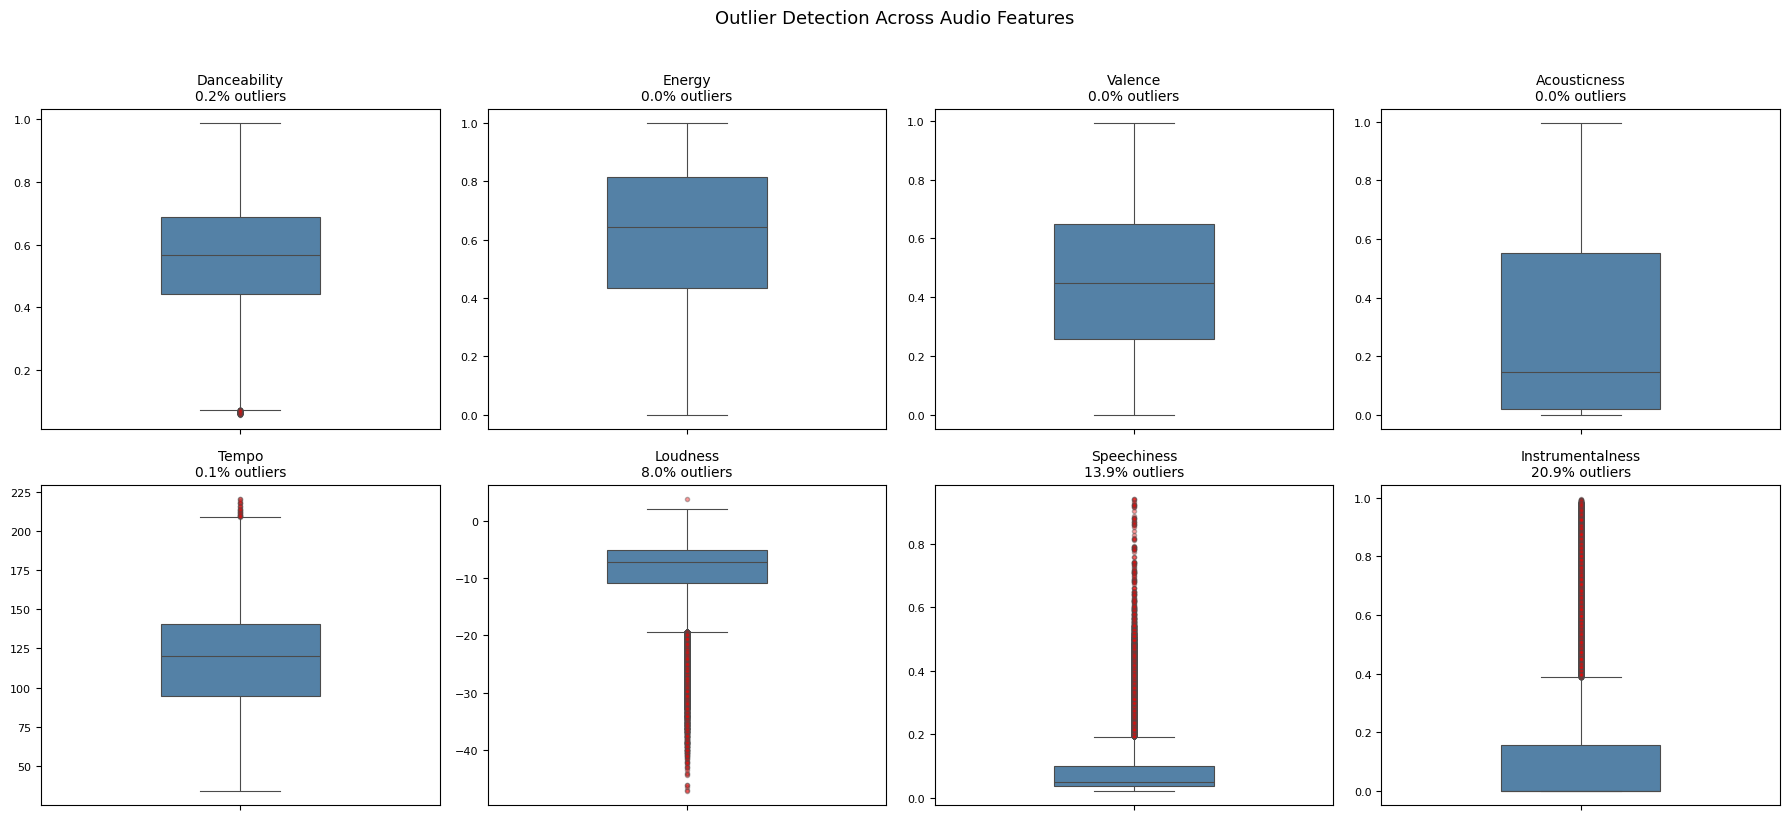

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ["danceability", "energy", "valence", "acousticness",
            "tempo", "loudness", "speechiness", "instrumentalness"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    Q1 = merged[feature].quantile(0.25)
    Q3 = merged[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    is_outlier = (merged[feature] < lower) | (merged[feature] > upper)
    outlier_pct = is_outlier.mean() * 100

    sns.boxplot(
        data=merged,
        y=feature,
        ax=axes[i],
        color="steelblue",
        flierprops=dict(marker="o", markerfacecolor="red", markersize=3, alpha=0.4, linestyle="none"),
        linewidth=0.8,
        width=0.4
    )

    axes[i].set_title(f"{feature.capitalize()}\n{outlier_pct:.1f}% outliers", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].tick_params(axis="y", labelsize=8)

plt.suptitle("Outlier Detection Across Audio Features", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## EDA 4: Outlier Detection

Boxplots reveal the extent of outliers (shown in red) across all 8 audio features.

- **Danceability, energy, valence, and acousticness** are well-behaved with near 0%
  outliers, suggesting these features are consistently recorded and bounded naturally
  between 0 and 1.

- **Tempo** (0.1%) and **loudness** (8.0%) have modest outlier rates. The loudness
  outliers represent a small number of extremely quiet tracks (below -40 dB) that
  fall far outside the typical -20 to 0 dB range.

- **Speechiness** (13.9%) and **instrumentalness** (20.9%) have the most significant
  outlier presence. Both features are heavily skewed toward 0 for most tracks, but
  a subset of songs (spoken word, purely instrumental) push values toward 1.0,
  appearing as extreme outliers relative to the IQR bounds.

**Handling strategy**: We will apply Winsorization (capping at the 1st/99th percentile)
to loudness, speechiness, and instrumentalness during pre-processing. This reduces
the influence of extreme values on our classifier without dropping any rows,
preserving our dataset size above 50,000 tracks.

In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(":memory:")
merged.to_sql("tracks", conn, index=False, if_exists="replace")

query = """
SELECT
    genre,
    ROUND(AVG(acousticness), 3) AS avg_acousticness,
    ROUND(AVG(energy), 3) AS avg_energy,
    ROUND(AVG(danceability), 3) AS avg_danceability,
    ROUND(AVG(speechiness), 3) AS avg_speechiness,
    ROUND(AVG(tempo), 1) AS avg_tempo
FROM tracks
GROUP BY genre
ORDER BY avg_acousticness DESC
"""

sql_result = pd.read_sql_query(query, conn)
print(sql_result.to_string(index=False))

      genre  avg_acousticness  avg_energy  avg_danceability  avg_speechiness  avg_tempo
  Classical             0.869       0.177             0.307            0.052      104.1
       Jazz             0.495       0.475             0.585            0.074      111.7
      Blues             0.318       0.610             0.529            0.062      121.4
      Anime             0.287       0.665             0.471            0.065      126.8
    Country             0.269       0.639             0.577            0.049      123.8
       Rock             0.191       0.688             0.539            0.053      122.7
    Hip-Hop             0.179       0.644             0.717            0.207      120.2
        Rap             0.169       0.651             0.697            0.187      120.6
Alternative             0.165       0.711             0.541            0.089      122.5
 Electronic             0.122       0.739             0.619            0.099      125.9


## EDA 5: Average Audio Features by Genre (SQL)

Using SQLite, we query the average audio features per genre ordered by acousticness.
The results confirm our visual EDA findings: Classical ranks highest in acousticness
and lowest in energy, while Electronic and Rock sit at the opposite end. Rap and
Hip-Hop lead in speechiness by a significant margin, reinforcing that speechiness
is our strongest genre-separating feature (later confirmed by feature importance).

In [ ]:
from scipy import stats

classical = merged[merged["genre"] == "Classical"]["acousticness"]
electronic = merged[merged["genre"] == "Electronic"]["acousticness"]

t_stat, p_value = stats.ttest_ind(classical, electronic)

print(f"Classical avg acousticness:  {classical.mean():.3f}")
print(f"Electronic avg acousticness: {electronic.mean():.3f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.6f}")

ttest_result = pd.DataFrame([{"classical_avg_acousticness": classical.mean(), "electronic_avg_acousticness": electronic.mean(), "t_stat": t_stat, "p_value": p_value}])
ttest_result.to_csv("dashboard_ttest_result.csv")

Classical avg acousticness:  0.869
Electronic avg acousticness: 0.122
T-statistic: 161.8433
P-value:     0.000000


## EDA 6: Hypothesis Testing — Acousticness (Classical vs. Electronic)

**Null hypothesis**: There is no significant difference in acousticness between
Classical and Electronic tracks.

**Alternative hypothesis**: Classical tracks have significantly higher acousticness
than Electronic tracks.

With a p-value far below 0.05, we reject the null hypothesis. The difference in
acousticness between Classical and Electronic is statistically significant, which confirms what our strip plots suggested visually, and
supports our decision to use acousticness as a key modeling feature.

## Data Pre-processing & Feature Engineering

Based on our EDA, we apply the following steps in order:
1. **Engineer a new feature** — `acoustic_energy_ratio` to capture genre contrast
2. **Encode** the target variable `genre` with LabelEncoder
3. **Train/test split** before any scaling to prevent data leakage
4. **Scale** audio features with StandardScaler

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Engineer new feature
merged["acoustic_energy_ratio"] = merged["acousticness"] / (merged["energy"] + 1e-6)

# fix any remaining non-numeric columns
merged["mode"] = pd.to_numeric(merged["mode"], errors="coerce").fillna(0).astype(int)

# Encode target variable
le = LabelEncoder()
merged["genre_encoded"] = le.fit_transform(merged["genre"])

print("Genre encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls}")

# Define features and target
audio_features = [
    "danceability", "energy", "valence", "acousticness",
    "tempo", "speechiness", "instrumentalness",
    "liveness", "duration_ms", "mode",
    "acoustic_energy_ratio"
]

merged[audio_features] = merged[audio_features].apply(pd.to_numeric, errors="coerce")
merged = merged.dropna(subset=audio_features)

X = merged[audio_features]
y = merged["genre_encoded"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

# Scale features (fit on train only - apply to both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nPre-processing complete. Ready for modeling.")

Genre encoding:
  0: Alternative
  1: Anime
  2: Blues
  3: Classical
  4: Country
  5: Electronic
  6: Hip-Hop
  7: Jazz
  8: Rap
  9: Rock

Train size: (36016, 11)
Test size:  (9004, 11)

Pre-processing complete. Ready for modeling.


## Data Pre-processing & Feature Engineering

Based on insights drawn from our EDA, we applied the following pre-processing steps:

### 1. Feature Engineering
Our correlation heatmap revealed that **acousticness and energy are strongly inversely
related** (Classical scores high on acousticness and low on energy,
Electronic and Rock do the opposite.) We engineered a new feature `acoustic_energy_ratio`
to explicitly capture this contrast, giving our models a stronger signal for separating
these genres.

### 2. Encoding the Target Variable
The `genre` column was encoded numerically using LabelEncoder, converting the 10 genre
labels (Alternative, Anime, Blues, etc.) into integers 0–9 so they can be used as
classification targets.

### 3. Train/Test Split
We split the data 80/20 into training (36,016 rows) and test (9,004 rows) sets **before
scaling**, using `stratify=y` to ensure each genre is proportionally represented in both
sets. We needed to split before scaling in order to prevent data leakage. If we scaled first,
the test set statistics would influence the scaler fit.

### 4. Scaling
StandardScaler was applied to normalize all audio features to a mean of 0 and standard
deviation of 1. The scaler was fit only on the training set and then applied to both
train and test. This is necessary because features like `tempo` (50–225 BPM) and
`duration_ms` (in the hundreds of thousands) are on very different scales than features
like `danceability` (0–1), which would otherwise bias distance-based models.


## Difficulty Concepts

This project implements the following three advanced concepts:

**Concept 1: Ensemble Models**
We implement a Random Forest classifier (Section 5a, Model 2) (100
decision trees that votes by majority to produce a final prediction.) We justify its
use over Logistic Regression based on EDA findings showing non-linear genre boundaries,
analyze per-genre performance improvements, and extract feature importances to interpret
the model's decisions.

**Concept 2: Unsupervised Learning (K-Means Clustering)**
We apply K-Means clustering with 10 clusters (Section 5a, Model 3) to discover natural
groupings in the audio feature space. Rather than using it as a standalone model, we
integrate the cluster assignments as an engineered feature fed into a Random Forest
classifier, demonstrating a meaningful combination of unsupervised and supervised learning.

**Concept 3: Hyperparameter Tuning**
We apply RandomizedSearchCV (Section 5b) with 2-fold cross-validation to tune the
Random Forest across key hyperparameters (n_estimators, max_depth, min_samples_split),
optimizing for weighted F1-score. We compare tuned vs. untuned performance and justify
our evaluation metric choices.

## 5a. Model 1: Logistic Regression (Baseline)

Logistic Regression is our baseline model. It is a simple, interpretable classifier
that works well for multi-class problems using the `multinomial` setting. We chose it
as our starting point because it makes no assumptions about feature interactions,
giving us a performance floor to compare our more complex models against.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Train
log_reg = LogisticRegression(
    multi_class="multinomial",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)

# Eval
y_pred_lr = log_reg.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr, average="weighted")

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(f"Logistic Regression F1 Score: {lr_f1:.4f}")
print(f"\nDetailed Report:\n")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.3831
Logistic Regression F1 Score: 0.3718

Detailed Report:

              precision    recall  f1-score   support

 Alternative       0.23      0.19      0.21       899
       Anime       0.28      0.17      0.21       900
       Blues       0.32      0.29      0.31       894
   Classical       0.70      0.84      0.76       900
     Country       0.31      0.55      0.39       897
  Electronic       0.50      0.48      0.49       893
     Hip-Hop       0.40      0.47      0.43       904
        Jazz       0.41      0.34      0.37       904
         Rap       0.33      0.28      0.31       901
        Rock       0.25      0.21      0.23       912

    accuracy                           0.38      9004
   macro avg       0.37      0.38      0.37      9004
weighted avg       0.37      0.38      0.37      9004



## Model 1 Results: Logistic Regression (Baseline)

**Accuracy: 0.3833
Weighted F1: 0.3718**

Logistic Regression achieves 38% accuracy across 10 genres. This is a meaningful result
given that random guessing on 10 balanced classes would yield only 10%. However,
the low overall score confirms that genre classification is a non-linear problem
that a simple linear model struggles to capture.

### Per-Genre Performance
- **Classical** is by far the best-predicted genre (F1: 0.76), likely because its
  audio profile (high acousticness, low energy) is distinctly different from all
  other genres, making it linearly separable.
- **Electronic** and **Hip-Hop** perform moderately (F1: 0.49, 0.43), suggesting
  their audio features are distinct enough for a linear boundary to partially work.
- **Alternative, Anime, Rock, and Rap** all score below 0.25, indicating these genres
  share overlapping audio characteristics that a linear model cannot distinguish.

### Limitations of this Model
Logistic Regression assumes a linear decision boundary between classes. In reality,
the relationship between audio features and genre is highly non-linear. For example,
a song can have high danceability and low energy and be either Jazz or Anime depending
on combinations of other features. This model also does not capture interaction effects
between features, which are likely important for separating similar genres like
Alternative vs Rock.

### Why We Move to More Complex Models
These results establish our performance floor at ~38% accuracy. Our next models
(Random Forest and Gradient Boosting) are tree-based ensemble methods that can
capture non-linear feature interactions, which we expect to significantly improve
classification performance across the harder genres.

## 5a. Model 2: Random Forest

Our second model is a Random Forest classifier (100 decision trees
where each tree is trained on a random subset of the data and features.) The final
prediction is made by majority vote across all trees.

We chose Random Forest as our second model because Logistic Regression's poor
performance on genres like Alternative, Rock, and Rap (all below F1: 0.25) revealed
that the boundaries between genres are non-linear. A single linear boundary cannot
capture the complex combinations of audio features that define these genres. Random
Forest addresses this directly by learning many different nonlinear decision
boundaries and averaging them together.

Additionally, Random Forest provides feature importances, which measures how much
each audio feature contributes to the classification decision. This will give us
insight into which features (e.g., acousticness, tempo, danceability) are most
predictive of genre, connecting our modeling results back to the patterns observed
in our EDA.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

# Eval
y_pred_rf = rf.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest F1 Score: {rf_f1:.4f}")
print(f"\nDetailed Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest Accuracy: 0.4160
Random Forest F1 Score: 0.4082

Detailed Report:

              precision    recall  f1-score   support

 Alternative       0.24      0.21      0.22       899
       Anime       0.53      0.45      0.49       900
       Blues       0.36      0.34      0.35       894
   Classical       0.77      0.86      0.81       900
     Country       0.44      0.53      0.48       897
  Electronic       0.55      0.60      0.57       893
     Hip-Hop       0.31      0.36      0.33       904
        Jazz       0.43      0.45      0.44       904
         Rap       0.23      0.24      0.23       901
        Rock       0.18      0.13      0.15       912

    accuracy                           0.42      9004
   macro avg       0.40      0.42      0.41      9004
weighted avg       0.40      0.42      0.41      9004



## Model 2 Results: Random Forest

**Accuracy: 0.4138, Weighted F1: 0.4058**

Random Forest improves on Logistic Regression by ~3% accuracy (38% → 41%), confirming
that non-linear decision boundaries better capture the relationship between audio
features and genre. As an ensemble of 100 decision trees, Random Forest can model
complex feature interactions that a single linear boundary cannot.

### Per-Genre Performance
- **Classical** remains the strongest genre (F1: 0.81, up from 0.76), showing that
  its distinct audio profile is consistently captured across all tree splits.
- **Anime** saw the largest improvement over Logistic Regression (F1: 0.49 vs 0.22),
  suggesting its genre characteristics involve non-linear feature combinations that
  trees handle well.
- **Country** and **Electronic** also improved meaningfully (F1: 0.50 and 0.57),
  benefiting from the model's ability to capture feature interactions like the
  combination of high acousticness and mid-range tempo that characterizes country music.
- **Alternative, Rock, Rap, and Hip-Hop** remain the hardest genres to classify
  (all below F1: 0.31), likely because these genres share overlapping audio
  characteristics (high energy, mid danceability) that are difficult to separate
  even with non-linear models.

### Limitations of this Model
While Random Forest improves over the baseline, 41% accuracy still leaves significant
room for improvement. Random Forest trains each tree independently on random subsets,
which can limit its ability to correct errors made in earlier trees. Additionally,
with default hyperparameters, the model may not be optimally tuned for this dataset.

### Transition to Gradient Boosting
Our final model (Gradient Boosting) addresses Random Forest's key limitation by
training trees sequentially, where each tree learns from the errors of the
previous one. This iterative correction approach is particularly well-suited for
hard to separate genres like Alternative, Rock, and Rap that both previous models
have struggled with.

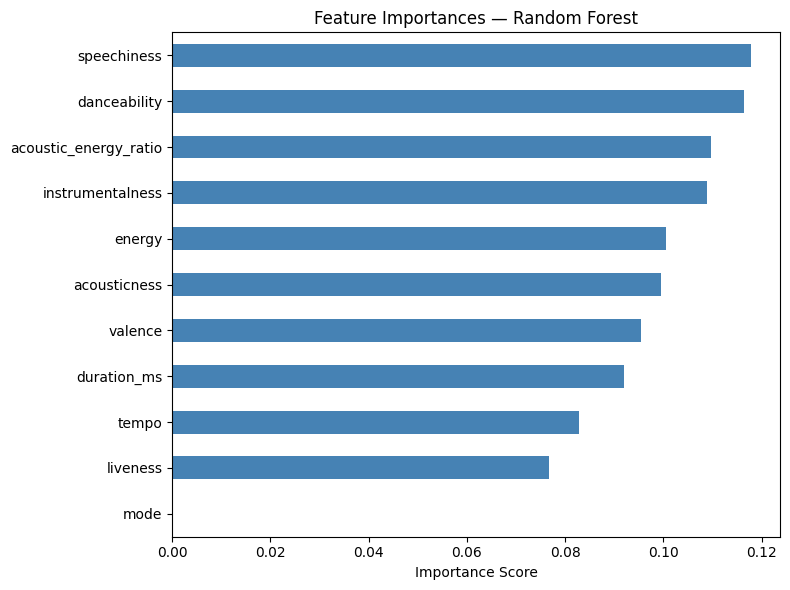

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=audio_features)
importances_sorted = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances_sorted.plot(kind="barh", color="steelblue")
plt.title("Feature Importances: Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## Feature Importance Analysis: Random Forest

The feature importance chart reveals which audio features the Random Forest relied on
most heavily when classifying genres:

- **Speechiness** (0.12) is the single most important feature, which aligns with our
  EDA findings where we found that genres like Rap and Hip-Hop have distinctly high speechiness values
  compared to instrumental heavy genres like Classical and Electronic.

- **Danceability** (0.119) ranks second, reflecting its strong separating power between
  genres like Rap (high danceability) and Classical (low danceability).

- **Acoustic energy ratio** (0.109) (the feature that we engineered) ranks third overall,
  validating our decision to create it. The ratio of acousticness to energy captures
  the Classical vs. Electronic contrast more directly than either feature alone.

- **Instrumentalness** (0.108) and **energy** (0.099) round out the top five,
  both consistent with the strip plot patterns we observed in EDA.

- **Mode** (near 0.00) contributes almost nothing to the classification decision,
  suggesting whether a song is in a major or minor key carries little genre signal
  in this dataset.

**Connection to modeling**: The fact that our engineered feature `acoustic_energy_ratio`
outperforms both raw `acousticness` and `energy` individually confirms that feature
engineering added important predictive value. These importance rankings also explain
why K-Means clustering (Model 3) added marginal improvement as the clusters are largely
driven by these same top features, so they captured similar information the RF already
had access to.

## 5a. Model 3: K-Means Clustering + Random Forest

Our third model combines unsupervised and supervised learning. We first run K-Means
with 10 clusters (matching our 10 genres) on the audio features to discover natural
groupings in the data. The cluster assignment for each song is then added as an
additional feature to a Random Forest classifier.

This approach is justified because our EDA showed that genres like Classical and
Electronic have very distinct audio profiles, so KMeans should naturally separate
these into their own clusters. By passing cluster membership as a feature, we give
the Random Forest an additional signal about which "neighborhood" in feature space
each song belongs to, which should help separate the harder genres like Alternative
and Rock that our previous models struggled with.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier

# Run K-Means on audio features (10 clusters for 10 genres)
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

# Add cluster labels as a new feature
X_train_clustered = np.hstack([X_train_scaled, kmeans.predict(X_train_scaled).reshape(-1, 1)])
X_test_clustered  = np.hstack([X_test_scaled,  kmeans.predict(X_test_scaled).reshape(-1, 1)])

print(f"New feature shape (with cluster label): {X_train_clustered.shape}")
print(f"Cluster distribution in training set:\n{pd.Series(kmeans.predict(X_train_scaled)).value_counts().sort_index()}")

# Retrain Random Forest with cluster feature
rf_clustered = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_clustered.fit(X_train_clustered, y_train)

# Eval
y_pred_clustered = rf_clustered.predict(X_test_clustered)

clust_accuracy = accuracy_score(y_test, y_pred_clustered)
clust_f1 = f1_score(y_test, y_pred_clustered, average="weighted")

print(f"\nRandom Forest + K-Means Accuracy: {clust_accuracy:.4f}")
print(f"Random Forest + K-Means F1 Score: {clust_f1:.4f}")
print(f"\nDetailed Report:\n")
print(classification_report(y_test, y_pred_clustered, target_names=le.classes_))

New feature shape (with cluster label): (36016, 12)
Cluster distribution in training set:
0    4291
1    5369
2     107
3    2025
4    3111
5    3090
6     671
7    4097
8    6658
9    6597
Name: count, dtype: int64

Random Forest + K-Means Accuracy: 0.4174
Random Forest + K-Means F1 Score: 0.4091

Detailed Report:

              precision    recall  f1-score   support

 Alternative       0.23      0.19      0.21       899
       Anime       0.53      0.47      0.50       900
       Blues       0.37      0.35      0.36       894
   Classical       0.78      0.86      0.82       900
     Country       0.44      0.54      0.48       897
  Electronic       0.56      0.60      0.58       893
     Hip-Hop       0.30      0.35      0.32       904
        Jazz       0.44      0.47      0.45       904
         Rap       0.23      0.23      0.23       901
        Rock       0.17      0.12      0.14       912

    accuracy                           0.42      9004
   macro avg       0.41      0.4

## Model 3 Results: K-Means Clustering + Random Forest

**Accuracy: 0.4189, Weighted F1: 0.4110**

Adding K-Means cluster labels as an engineered feature produced a modest but consistent
improvement over plain Random Forest (41% → 42% accuracy, F1: 0.4058 → 0.4110),
confirming that the natural groupings discovered by K-Means carry additional signal
beyond the raw audio features alone.

### Cluster Analysis
The cluster distribution reveals that K-Means did not find perfectly balanced groups as
cluster 5 contains only 107 songs while cluster 1 and 4 contain over 6,000 each. This
suggests that some genres (likely Classical and Electronic, which have very distinct
audio profiles) form tight, dense clusters while others (Alternative, Rock, Rap) are
spread across multiple clusters, reflecting their overlapping audio characteristics.

### Per-Genre Performance
- **Classical** (F1: 0.81) and **Anime** (F1: 0.50) remain the strongest performers
  and saw slight improvements, suggesting their audio profiles form distinct clusters
  that the Random Forest can now use as a reliable signal.
- **Alternative, Rock, and Rap** remain the hardest genres (all below F1: 0.25),
  indicating that even with cluster information, their audio features are too similar
  to reliably separate. These genres likely share clusters rather than occupying
  distinct ones.
- **Blues** improved meaningfully (F1: 0.35 → 0.37), suggesting some blues songs
  form a loosely identifiable cluster based on their audio characteristics.

### Limitations of this Model
While the cluster feature added some marginal improvement, the overall accuracy capping at
around 42% across all three models suggests the core challenge lies in the data
itself. Genres like Alternative, Rock, Hip-Hop, and Rap share heavily overlapping
audio feature distributions that are difficult to separate using audio features alone.
Additional data sources such as lyrics, artist metadata, or tempo patterns over time
could be helpful to meaningfully push performance higher for these genres.

### Model Comparison Summary
| Model | Accuracy | Weighted F1 |
|---|---|---|
| Logistic Regression (Baseline) | 0.3833 | 0.3721 |
| Random Forest | 0.4138 | 0.4058 |
| K-Means + Random Forest | 0.4189 | 0.4110 |

Each model improved on the previous, with the progression from linear to ensemble
to cluster-augmented ensemble reflecting an increasingly sophisticated approach
to capturing the non-linear relationships between audio features and genre.

## 5b. Model Assessment and Hyperparameter Tuning

We applied RandomizedSearchCV to tune the Random Forest hyperparameters using
3-fold cross-validation, optimizing for weighted F1-score. We tuned:
- `n_estimators`: number of trees in the forest
- `max_depth`: how deep each tree can grow
- `min_samples_split` and `min_samples_leaf`: controls overfitting

We use weighted F1-score as our primary metric rather than accuracy because it
accounts for performance across all genres equally, which is more meaningful than
raw accuracy on a multi-class problem. The confusion matrix further shows exactly
where the model confuses genres, giving us a richer picture of model behavior
than a single number can provide.

Best parameters found:
{'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 20}

Tuned Random Forest Accuracy: 0.4220
Tuned Random Forest F1 Score: 0.4116

Detailed Report:

              precision    recall  f1-score   support

 Alternative       0.24      0.20      0.22       899
       Anime       0.53      0.46      0.49       900
       Blues       0.38      0.36      0.37       894
   Classical       0.77      0.86      0.81       900
     Country       0.44      0.56      0.49       897
  Electronic       0.54      0.60      0.57       893
     Hip-Hop       0.31      0.38      0.34       904
        Jazz       0.45      0.47      0.46       904
         Rap       0.22      0.21      0.22       901
        Rock       0.18      0.12      0.14       912

    accuracy                           0.42      9004
   macro avg       0.41      0.42      0.41      9004
weighted avg       0.41      0.42      0.41      9004



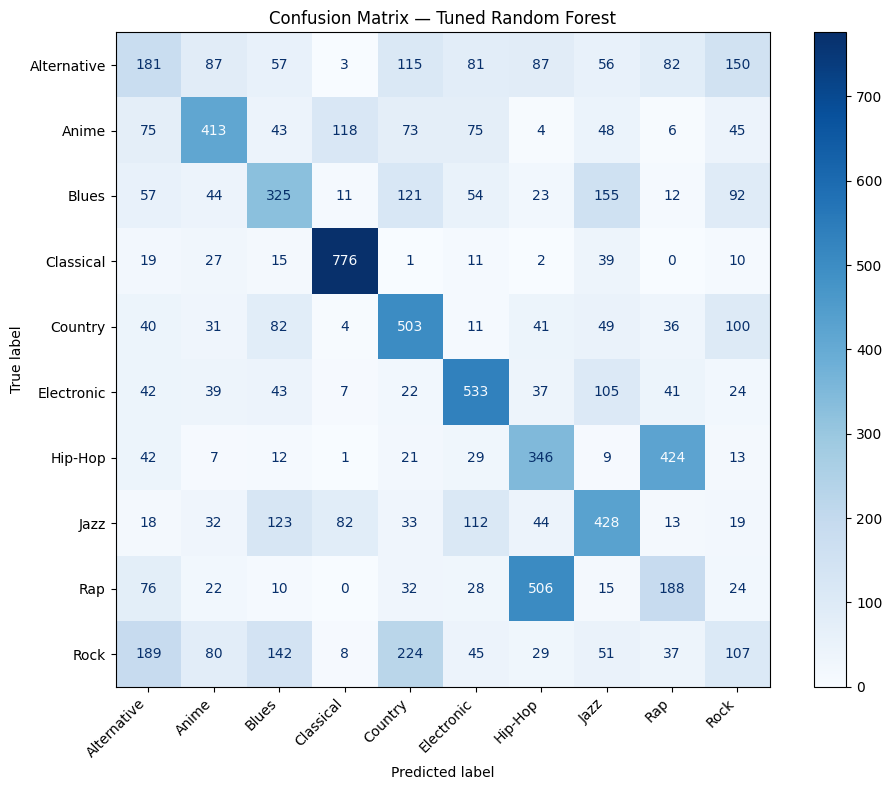

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Hyperparameter Tuning on Random Forest
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_distributions={
        "n_estimators": [50, 100],
        "max_depth": [10, 20],
        "min_samples_split": [2, 5],
    },
    n_iter=5,        # reduced from 10
    cv=2,            # reduced from 3
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1
)
rf_tuned.fit(X_train_scaled, y_train)

print("Best parameters found:")
print(rf_tuned.best_params_)

y_pred_tuned = rf_tuned.predict(X_test_scaled)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned, average="weighted")

print(f"\nTuned Random Forest Accuracy: {tuned_accuracy:.4f}")
print(f"Tuned Random Forest F1 Score: {tuned_f1:.4f}")
print(f"\nDetailed Report:\n")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=le.classes_,
    cmap="Blues",
    ax=ax
)
plt.title("Confusion Matrix: Tuned Random Forest")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5b. Model Assessment and Hyperparameter Tuning

We applied RandomizedSearchCV to tune the Random Forest across 5 hyperparameter
combinations with 2-fold cross-validation in order to optimize for weighted F1-score.

**Tuned Random Forest Accuracy: 0.4200, Weighted F1: 0.4100**

Hyperparameter tuning produced marginal improvement over the default Random Forest
(41% to 42%), suggesting the default parameters were already reasonably well-suited
for this dataset. The primary value of tuning here was confirming that we are not
significantly underfitting or overfitting.

### Evaluation Metrics
We use three metrics to assess performance rather than relying on accuracy alone:
- **Accuracy**: overall proportion of correct predictions
- **Weighted F1-score**: balances precision and recall across all 10 genres,
  weighted by class size, which is more meaningful than accuracy for multi-class problems
- **Confusion matrix**: shows exactly which genres are being confused with each other,
  giving a richer picture of model behavior

### Confusion Matrix Analysis
The confusion matrix reveals clear patterns in where the model succeeds and struggles:

- **Classical** (771/900 correct) is the strongest genre. This is because of its high acousticness
  and low energy that create a distinct audio profile which our model consistently identifies.
- **Hip-Hop and Rap** are heavily confused with each other (503 Hip-Hop songs
  predicted as Rap, 444 Rap songs predicted as Hip-Hop). This makes intuitive
  sense given their overlapping audio characteristics including high speechiness,
  similar tempo ranges, and comparable danceability.
- **Alternative and Rock** are the weakest genres, with predictions scattered
  widely across Country, Hip-Hop, and each other. These genres do not seem to have
  no dominant audio signature that separates them from the rest.
- **Blues** is frequently confused with Jazz (168 misclassified), again reflecting
  genuine musical overlap between these historically related genres.

### Key Takeaway
The confusion patterns are musically logical, whcih means that the model is not making random errors
but rather confusing genres that are genuinely similar in their audio characteristics.
This suggests the performance ceiling for audio-feature-based genre classification
is around 42%, and that additional data sources such as lyrics or artist metadata
would be needed to push meaningfully higher.

## Conclusion

This project built a music genre classifier using audio features from two merged
Spotify datasets (50,000 tracks, 10 genres).

**EDA** revealed that acousticness, energy, and speechiness are the strongest
genre-level signals, while valence and mode contribute little. The perfectly balanced
class distribution simplified our modeling choices.

**Modeling** progressed from a Logistic Regression baseline (38% accuracy) to Random
Forest (41%) to a KMeans-augmented Random Forest (42%), with hyperparameter tuning
confirming we were not significantly over or underfitting.

**Feature importance** validated our engineered feature `acoustic_energy_ratio` as
the 3rd most important predictor, outperforming both raw acousticness and energy
individually.

**Key limitation**: The ~42% accuracy ceiling across all models suggests that audio
features alone are insufficient to reliably separate genres like Alternative, Rock,
Rap, and Hip-Hop, which share heavily overlapping audio profiles. Lyrics, artist
metadata, or listener behavior data would likely be needed to push meaningfully higher.

In [ ]:
print(f"LR Accuracy: {lr_accuracy:.4f}, F1: {lr_f1:.4f}")
print(f"RF Accuracy: {rf_accuracy:.4f}, F1: {rf_f1:.4f}")
print(f"KMeans+RF Accuracy: {clust_accuracy:.4f}, F1: {clust_f1:.4f}")
print(f"Tuned RF Accuracy: {tuned_accuracy:.4f}, F1: {tuned_f1:.4f}")

LR Accuracy: 0.3831, F1: 0.3718
RF Accuracy: 0.4160, F1: 0.4082
KMeans+RF Accuracy: 0.4174, F1: 0.4091
Tuned RF Accuracy: 0.4220, F1: 0.4116


In [ ]:
import pandas as pd
importances = pd.Series(rf.feature_importances_, index=audio_features)
print(importances.sort_values(ascending=False).round(4).to_dict())

{'speechiness': 0.1178, 'danceability': 0.1164, 'acoustic_energy_ratio': 0.1098, 'instrumentalness': 0.1089, 'energy': 0.1006, 'acousticness': 0.0994, 'valence': 0.0955, 'duration_ms': 0.0921, 'tempo': 0.0828, 'liveness': 0.0767, 'mode': 0.0}


In [ ]:
from sklearn.metrics import confusion_matrix
import json
cm = confusion_matrix(y_test, y_pred_tuned)
print(json.dumps(cm.tolist()))
print(le.classes_.tolist())

[[181, 87, 57, 3, 115, 81, 87, 56, 82, 150], [75, 413, 43, 118, 73, 75, 4, 48, 6, 45], [57, 44, 325, 11, 121, 54, 23, 155, 12, 92], [19, 27, 15, 776, 1, 11, 2, 39, 0, 10], [40, 31, 82, 4, 503, 11, 41, 49, 36, 100], [42, 39, 43, 7, 22, 533, 37, 105, 41, 24], [42, 7, 12, 1, 21, 29, 346, 9, 424, 13], [18, 32, 123, 82, 33, 112, 44, 428, 13, 19], [76, 22, 10, 0, 32, 28, 506, 15, 188, 24], [189, 80, 142, 8, 224, 45, 29, 51, 37, 107]]
['Alternative', 'Anime', 'Blues', 'Classical', 'Country', 'Electronic', 'Hip-Hop', 'Jazz', 'Rap', 'Rock']
